# Player Engagement & Retention Analysis


### Introduction

This notebook documents the cleaning and exploratory analysis of a simulated dataset for a fictional live-service video game. The primary language used for this project is Python. Libraries used include numpy and pandas. Dashboards and final data visualization for this project can be found at https://public.tableau.com/views/PlayerEngagementandRetention-MythicQuest/Sheet1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link.

##### Industry: Video Games/Live-Service Games
##### Company Type: Major Publisher
##### Primary Audience: Product Managers/Game Designers (responsible for content scope, cadence, and post-launch tuning)

##### Core Analytical Question
* How do player engagement and retention metrics change before and after a major content update, and which player segments are most affected?
##### Additional Stakeholder Questions
* Which features or content introduced in the update are most associated with increases or decreases in engagement among different player segments?
* Are there identifiable patterns of player behavior post-update that predict long-term retention or churn for high-value segments?


### Objective

The objective of this analysis is to enable stakeholders (e.g., product managers, live-ops teams, and game designers) to evaluate the impact of a major content update on player engagement and retention and to identify which player segments are positively or negatively affected.

By comparing pre- and post-update engagement scores and D1/D7/D30 retention outcomes across player segments, this analysis should allow stakeholders to:
* Assess whether the content update successfully increased short-term and long-term player retention
* Identify segments at risk of disengagement or churn following the update
* Understand how engagement behaviors (frequency, session depth, and social interaction) relate to post-update retention
* Inform future content, live-ops timing, and targeted interventions aimed at improving player retention and sustained engagement

Ultimately, this analysis is intended to support data-informed decisions about content design, update cadence, and post-update player targeting in a live-service game environment.


### Definitions

##### Engagement
For the sake of this analysis, a player can be considered engaged based on three criteria: session frequency (played at least 16 days during the measured period), session duration (played for at least 30 minutes per session), and social interaction (had at least 10 social interactions per session). I developed the following formulae to determine an "engagement score" for each player:

1. Frequency score $F=\frac{Days\:played\:in\:period}{Target\:days}$

2. Duration score $D=\frac{Average\:session\:duration}{Target\:duration}$

3. Social score $S=\frac{Average\:social\:interactions\:per\:session}{Target\:number}$

4. Engagement score $E=F \times D \times S$

Frequency, duration, and social scores are weighted equally for the purpose of this analysis. An engagement score $\ge$ 1 will indicate a player that demonstrates meaningful engagement across all three behavioral dimensions (and can therefore be considered engaged).

##### Retention
For the sake of this analysis, a player is considered retained if they return to the game and demonstrate continued activity after the reference point (in this case, a major content update). Retention is defined using industry-standard benchmarks with window-based criteria:

D1 Retention: Player logged in and completed at least one gameplay session 1 day after the content update

D7 Retention: Player logged in and completed at least one gameplay session within 7 days after the content update

D30 Retention: Player logged in and completed at least one gameplay session within 30 days after the content update

A “gameplay session” is defined as a session meeting the minimum activity threshold (≥ 30 minutes of playtime), ensuring retention reflects meaningful return behavior rather than a trivial login. These retention metrics are cumulative window-based measures and are used to assess short-, mid-, and long-term player return behavior following the update.


### Important Information
Content update launch day: June 15, 2024.
Time period represented in this dataset: April 16, 2024 to August 14, 2024. 

### Assumptions and Limitations

This analysis uses a simulated dataset designed to approximate realistic player behavior in a live-service game. Results are illustrative and demonstrate analytical approach rather than real-world performance.

Engagement is measured using a composite score based on session frequency, duration, and social interaction. These metrics act as behavioral proxies and do not capture qualitative factors such as player sentiment or satisfaction.

Frequency, duration, and social interaction are weighted equally in the engagement score. This assumes comparable impact across dimensions, which may vary by genre or player segment and would require validation in a production environment.

Retention is defined as returning to the game and completing at least one session of ≥ 30 minutes. This prioritizes meaningful engagement but may exclude shorter, intentional player interactions.

Pre- vs. post-update comparisons assume the content update is the primary driver of observed changes. External influences (e.g., marketing efforts, seasonality, competing releases) are not explicitly controlled for, so findings should be interpreted as associative rather than causal.

### Data Loading and Audit

The code block below imports the dataset and displays the first five records to confirm the dataset loaded correctly.

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('player_engagement_data.csv')
print(df.head(15))

   session_id  player_id    game_title        date  session_duration_min  \
0   S00000001  P00010000  Mythic Quest  2024-04-26                 101.0   
1   S00000002  P00010000  Mythic Quest  2024-05-01                 145.0   
2   S00000003  P00010000  Mythic Quest  2024-05-25                   NaN   
3   S00000004  P00010000  Mythic Quest  2024-05-27                  27.0   
4   S00000005  P00010000  Mythic Quest  2024-06-03                 134.0   
5   S00000006  P00010000  Mythic Quest  2024-07-05                 155.0   
6   S00000007  P00010000  Mythic Quest  2024-07-08                 138.0   
7   S00000008  P00010001  Mythic Quest  2024-05-05                 137.0   
8   S00000009  P00010001  Mythic Quest  2024-05-13                  25.0   
9   S00000010  P00010001  Mythic Quest  2024-05-18                  10.0   
10  S00000011  P00010001  Mythic Quest  2024-06-01                  69.0   
11  S00000012  P00010002  Mythic Quest  2024-05-10                 164.0   
12  S0000001


Next, I print the datatypes of the dataset so I can get a feel for the information contained in the dataset and see whether the columns are typed correctly.

In [2]:
print("\n--- Datatypes ---")
print(df.dtypes)


--- Datatypes ---
session_id                object
player_id                 object
game_title                object
date                      object
session_duration_min     float64
in_game_purchases_usd    float64
level                     object
platform                  object
region                    object
player_type               object
account_age_category      object
achievement_count        float64
social_interactions      float64
churn_flag                object
dtype: object


Right away, I can see that the 'level' column is mistyped. Although player level is stored numerically, it represents an ordinal progression rather than a continuous quantitative measure. So I convert the 'level' column to an object datatype.

In [3]:
df['level'] = df['level'].astype(object)

I also suspect that the 'churn_flag' column should be a boolean. I check the unique values in the 'churn_flag' column, convert the "No"s to 0 and the "Yes"s to 1, and convert the column's datatype to bool.

In [4]:
df['churn_flag'] = (
    df['churn_flag']
      .replace({'Yes': 1, 'No': 0})
      .pipe(pd.to_numeric, errors='coerce')
      .astype('boolean')
)

The last datatype I want to update is for the 'date' column. I convert it to a datetime type.

In [5]:
df['date'] = pd.to_datetime(df['date'])

I check my work and make sure that all datatypes are now correct.

In [6]:
print("\n--- Datatypes R1 ---")
print(df.dtypes)


--- Datatypes R1 ---
session_id                       object
player_id                        object
game_title                       object
date                     datetime64[ns]
session_duration_min            float64
in_game_purchases_usd           float64
level                            object
platform                         object
region                           object
player_type                      object
account_age_category             object
achievement_count               float64
social_interactions             float64
churn_flag                      boolean
dtype: object


Now that my data is typed correctly, I print a summary of the dataset so I can look for anomalies.

In [7]:
print("\n--- Statistical Summary (All Columns) ---")
print(df.describe(include='all'))


--- Statistical Summary (All Columns) ---
       session_id  player_id    game_title                           date  \
count       45049      45049         45049                          45049   
unique      45049       9653             1                            NaN   
top     S00000001  P00019999  Mythic Quest                            NaN   
freq            1          8         45049                            NaN   
mean          NaN        NaN           NaN  2024-06-12 16:55:39.723412224   
min           NaN        NaN           NaN            2024-04-16 00:00:00   
25%           NaN        NaN           NaN            2024-05-13 00:00:00   
50%           NaN        NaN           NaN            2024-06-12 00:00:00   
75%           NaN        NaN           NaN            2024-07-13 00:00:00   
max           NaN        NaN           NaN            2024-08-14 00:00:00   
std           NaN        NaN           NaN                            NaN   

        session_duration_min  in

Based on the number of rows and number of unique rows in the session_id column, there are no duplicate rows.
Based on the min and max values for the date column, the data in this set has come from the correct date range, and there are no entries from sessions outside of this date range.
Based on the min and max values for the session_duration_min, in_game_purchases_usd, and social_interactions columns, there are no negative values or extreme outliers in these columns.
Before moving on to the data cleaning phase, I note the unusual minimum value for the 'achievement_count' column so I can investigate.

I also build the framework for a table that I will use to track my changes during the cleaning process.

In [8]:
counts = []
counts.append({'step':'initial', 'rows': len(df), 'players': df['player_id'].nunique()})

### Data Cleaning and Preparation

I start with column-by-column checks to make sure spelling, capitalization, and whitespace are all used consistently. I also check column-specific parameters, as shown below. The following code block checks that every value in 'session_id' is formatted correctly and there are no missing sessions.

In [9]:
import re
from typing import Dict, Any

def validate_id_format(df: pd.DataFrame, col: str, prefix: str = None, digits: int = 8) -> Dict[str, Any]:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not in dataframe")

    orig = df[col]
    sample = orig.dropna().astype(str).str.strip()
    if sample.empty:
        return {
            'prefix': None,
            'pattern': None,
            'valid_mask': pd.Series([False] * len(df), index=df.index),
            'digits_str': pd.Series([pd.NA] * len(df), index=df.index, dtype="object"),
            'digits_int': pd.Series([pd.NA] * len(df), index=df.index, dtype="Int64"),
            'invalid_rows': df.copy()
        }

    used_prefix = (prefix.upper() if prefix is not None else sample.iloc[0][0].upper())
    pattern = rf'^{re.escape(used_prefix)}(\d{{{digits}}})$'

    s = orig.astype(str).str.strip()
    original_na_mask = orig.isna()

    digits_str = s.str.extract(pattern)[0]
    valid_mask = (~digits_str.isna()) & (~original_na_mask)

    digits_int = pd.Series(pd.NA, index=df.index, dtype="Int64")
    if valid_mask.any():
        digits_int.loc[valid_mask] = digits_str[valid_mask].astype(int)

    invalid_rows = df[~valid_mask].copy()

    return {
        'prefix': used_prefix,
        'pattern': pattern,
        'valid_mask': valid_mask,
        'digits_str': digits_str,
        'digits_int': digits_int,
        'invalid_rows': invalid_rows
    }


def assess_sequence(digits_int: pd.Series, df: pd.DataFrame = None, prefix: str = "S", digits: int = 8) -> Dict[str, Any]:
    present = digits_int.dropna().astype(int)
    if present.empty:
        summary = {
            'valid_count': 0,
            'duplicate_count': 0,
            'min_numeric_id': None,
            'max_numeric_id': None,
            'missing_count': None
        }
        return {
            'duplicate_rows': (df.iloc[0:0].copy() if df is not None else []),
            'duplicate_values': [],
            'missing_ids': [],
            'summary': summary
        }

    dup_mask = present.duplicated(keep=False)
    duplicate_values = sorted(present[dup_mask].unique().tolist())

    if df is not None:
        duplicate_rows = df.loc[present.index[dup_mask]].copy()
    else:
        duplicate_rows = duplicate_values

    mn = int(present.min())
    mx = int(present.max())
    full_set = set(range(mn, mx + 1))
    present_set = set(present.tolist())
    missing_nums = sorted(full_set - present_set)
    missing_ids = [f"{prefix}{n:0{digits}d}" for n in missing_nums]

    summary = {
        'valid_count': int(present.size),
        'duplicate_count': int(duplicate_rows.shape[0]) if isinstance(duplicate_rows, pd.DataFrame) else len(duplicate_values),
        'min_numeric_id': mn,
        'max_numeric_id': mx,
        'missing_count': len(missing_ids)
    }

    return {
        'duplicate_rows': duplicate_rows,
        'duplicate_values': duplicate_values,
        'missing_ids': missing_ids,
        'summary': summary
    }

validate_id_format(df, 'session_id')

fmt_res = validate_id_format(df, 'session_id')
print("Pattern used:", fmt_res['pattern'])
print("Invalid rows (first 10):")
display(fmt_res['invalid_rows'].head(10))
seq_res = assess_sequence(fmt_res['digits_int'], df=df, prefix=fmt_res['prefix'])
print("Sequence summary:", seq_res['summary'])
print("First 20 missing ids:", seq_res['missing_ids'][:20])
display(seq_res['duplicate_rows'].head(10))

Pattern used: ^S(\d{8})$
Invalid rows (first 10):


,session_id,player_id,game_title,date,session_duration_min,in_game_purchases_usd,level,platform,region,player_type,account_age_category,achievement_count,social_interactions,churn_flag


Sequence summary: {'valid_count': 45049, 'duplicate_count': 0, 'min_numeric_id': 1, 'max_numeric_id': 45049, 'missing_count': 0}
First 20 missing ids: []


,session_id,player_id,game_title,date,session_duration_min,in_game_purchases_usd,level,platform,region,player_type,account_age_category,achievement_count,social_interactions,churn_flag


'session_id' appears to be formatted correctly, and I can see from my summary above that there are no duplicate session IDs in this dataset, so I move on to the next column. For 'player_id', I begin by ensuring that every ID is formatted correctly.

In [10]:
validate_id_format(df, 'player_id')

{'prefix': 'P',
 'pattern': '^P(\\d{8})$',
 'valid_mask': 0        True
 1        True
 2        True
 3        True
 4        True
          ... 
 45044    True
 45045    True
 45046    True
 45047    True
 45048    True
 Length: 45049, dtype: bool,
 'digits_str': 0        00010000
 1        00010000
 2        00010000
 3        00010000
 4        00010000
            ...   
 45044    00019999
 45045    00019999
 45046    00019999
 45047    00019999
 45048    00019999
 Name: 0, Length: 45049, dtype: object,
 'digits_int': 0        10000
 1        10000
 2        10000
 3        10000
 4        10000
          ...  
 45044    19999
 45045    19999
 45046    19999
 45047    19999
 45048    19999
 Length: 45049, dtype: Int64,
 'invalid_rows': Empty DataFrame
 Columns: [session_id, player_id, game_title, date, session_duration_min, in_game_purchases_usd, level, platform, region, player_type, account_age_category, achievement_count, social_interactions, churn_flag]
 Index: []}

There are no incorrectly formatted player IDs. I also check to see if there are any players for whom the region, player_type, or account_age_category changed during the analysis period.

In [11]:
def has_inconsistent_attributes(group):
    region_values = group['region'].dropna().nunique()
    player_type_values = group['player_type'].dropna().nunique()
    account_age_values = group['account_age_category'].dropna().nunique()

    ## only flag inconsistency when there are 2 or more different non-NaN values (NaN values will be addressed later)
    return (
        (region_values > 1) or 
        (player_type_values > 1) or 
        (account_age_values > 1)
    )

inconsistent_players = df.groupby('player_id').filter(has_inconsistent_attributes)

print(f"There are {inconsistent_players['player_id'].nunique()} players with inconsistent information.")

There are 0 players with inconsistent information.


No player's region, player_type, or account_age_category changed during the analysis period, so there are no inconsistencies to investigate in this regard.

Next I check the 'date' column for any null (NaT) values.

In [12]:
num_missing_date = df['date'].isna().sum()
print(f"date NaT count: {num_missing_date}")

date NaT count: 0


I also check the min and max values of the 'date' column to make sure the desired range is covered (two months before and two months after the content update). The min and max values indicate that the desired range is covered.

Then I check 'session_duration_min' for missing values.

In [13]:
num_missing_duration = df['session_duration_min'].isna().sum()
print(f"session duration NaN count: {num_missing_duration}")

session duration NaN count: 2231


There are 2,231 missing values in 'session_duration_min'. Further research is required to determine why these values are missing. I start with a quick sanity check.

In [14]:
# basic counts + percent
n_total = len(df)
n_missing = df['session_duration_min'].isna().sum()
print(n_missing, "missing of", n_total, f"({n_missing/n_total:.1%})")

# peek at some missing rows
df[df['session_duration_min'].isna()].sample(10)

2231 missing of 45049 (5.0%)


,session_id,player_id,game_title,date,session_duration_min,in_game_purchases_usd,level,platform,region,player_type,account_age_category,achievement_count,social_interactions,churn_flag
41069,S00041070,P00019102,Mythic Quest,2024-08-04,NaN,NaN,38,NaN,ASIA,free,Intermediate,58.0,21.0,False
41496,S00041497,P00019198,Mythic Quest,2024-05-31,NaN,0.00,30,pc,NaN,Premium,New,50.0,14.0,False
22277,S00022278,P00014933,Mythic Quest,2024-07-28,NaN,NaN,37,pc,ASIA,NaN,Veteran,81.0,45.0,False
36623,S00036624,P00018093,Mythic Quest,2024-06-01,NaN,16.08,33,pc,SA,Free,veteran,26.0,26.0,False
31007,S00031008,P00016862,Mythic Quest,2024-07-05,NaN,0.00,30,PlayStation,na,NaN,veteran,9.0,53.0,False
37127,S00037128,P00018208,Mythic Quest,2024-04-17,NaN,11.58,39,pc,NaN,Casual,New,0.0,20.0,True
24947,S00024948,P00015527,Mythic Quest,2024-05-31,NaN,0.00,46,PlayStation,EU,NaN,New,22.0,NaN,False
20083,S00020084,P00014436,Mythic Quest,2024-06-09,NaN,18.65,12,NaN,ASIA,NaN,Veteran,31.0,0.0,False
23478,S00023479,P00015218,Mythic Quest,2024-06-28,NaN,3.13,44,PC,NaN,free,Veteran,29.0,55.0,False
11805,S00011806,P00012632,Mythic Quest,2024-04-29,NaN,NaN,5,PLAYSTATION,NaN,Free,Veteran,30.0,42.0,False


The preview does not make the reason for missingness immediately clear, so I check to see if other related columns are missing for the same records.

In [15]:
cols = ['date', 'platform','region', 'player_type', 'account_age_category', 'social_interactions']
df_missing = df[df['session_duration_min'].isna()]
df_missing[cols].info()
df_missing[cols].head(20)

<class 'pandas.core.frame.DataFrame'>
Index: 2231 entries, 2 to 45038
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  2231 non-null   datetime64[ns]
 1   platform              1582 non-null   object        
 2   region                1409 non-null   object        
 3   player_type           1892 non-null   object        
 4   account_age_category  1847 non-null   object        
 5   social_interactions   2090 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 87.1+ KB


,date,platform,region,player_type,account_age_category,social_interactions
2,2024-05-25,Xbox,NaN,NaN,new,45.0
46,2024-04-24,NaN,NaN,NaN,NaN,25.0
52,2024-05-20,PlayStation,na,Whale,new,NaN
90,2024-08-14,PLAYSTATION,na,Free,New,56.0
112,2024-07-08,NaN,ASIA,Premium,Intermediate,54.0
113,2024-04-20,PlayStation,SA,PREMIUM,NaN,14.0
119,2024-08-04,PlayStation,SA,PREMIUM,NaN,47.0
145,2024-05-06,pc,ASIA,Free,New,2.0
151,2024-08-01,PlayStation,na,Free,Veteran,13.0
155,2024-07-16,Xbox,na,Free,NaN,5.0


Almost half of the records with a missing session duration also have a missing region, but more research would be required to determine if the two are correlated. For now, I move on and compare distributions and frequencies for rows with versus without missing session durations.

In [16]:
# categorical columns to inspect
for c in cols:
    print("==", c, "==")
    print("missing rows:")
    print(df_missing[c].value_counts(dropna=False).head(10))
    print("overall:")
    print(df[c].value_counts(dropna=False).head(10))
    print()

== date ==
missing rows:
date
2024-04-29    31
2024-06-28    29
2024-04-26    28
2024-06-21    28
2024-06-10    28
2024-08-08    26
2024-07-06    26
2024-04-17    25
2024-07-02    25
2024-05-06    25
Name: count, dtype: int64
overall:
date
2024-05-03    451
2024-04-23    436
2024-06-06    435
2024-04-18    431
2024-05-02    420
2024-05-10    420
2024-04-25    418
2024-04-19    417
2024-05-04    415
2024-05-14    415
Name: count, dtype: int64

== platform ==
missing rows:
platform
NaN            649
pc             334
PC             325
PLAYSTATION    318
PlayStation    312
Xbox           293
Name: count, dtype: int64
overall:
platform
NaN            12858
pc              6686
PLAYSTATION     6468
PlayStation     6442
PC              6305
Xbox            6290
Name: count, dtype: int64

== region ==
missing rows:
region
NaN     822
SA      301
ASIA    300
EU      273
OCE     273
na      262
Name: count, dtype: int64
overall:
region
NaN     17143
ASIA     5835
OCE      5671
SA       5528


I can see that missing durations are spread across many dates rather than concentrated on a single outage day. That suggests missingness is not caused by a single-day instrumentation failure.

Many of the records missing session durations are also missing other values (e.g., 649 are also missing the platform). This indicates that rows with missing duration often also lack other metadata, which could indicate upstream log loss or incomplete events. In a real-world scenario, I would flag this to the appropriate team or investigate outside the dataset as needed. For the purposes of this project, I simply trim the rows that are missing session durations out of my dataset, since session duration is one of the metrics used in determining whether a player is engaged or not.

In [17]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['session_duration_min']).reset_index(drop=True)
num_missing_duration_test = df_clean['session_duration_min'].isna().sum()
print(f"session duration NaN count: {num_missing_duration_test} of {len(df_clean)}")

counts.append({'step':'drop_session_duration', 'rows': len(df_clean), 'players': df_clean['player_id'].nunique()})

session duration NaN count: 0 of 42818


Next, I check in_game_purchases_usd for NaN values.

In [18]:
num_zero_purchases = (df_clean['in_game_purchases_usd'] == 0).sum()
print(f"in_game_purchases_usd == 0 count: {num_zero_purchases}")
num_missing_purchases = df_clean['in_game_purchases_usd'].isna().sum()
print(f"in-game purchases NaN count: {num_missing_purchases}")

in_game_purchases_usd == 0 count: 14932
in-game purchases NaN count: 15115


I can see that some values in 'in_game_purchases_usd' are listed as 0, but there are also some NaN values. In a production environment, I would flag this for further investigation. However, because purchase history is not a factor in our established criteria for player engagement and retention, I will leave these values as they are for now. In my analysis, I will treat NaN values as "unknown" and will compute any relevant insights using payers only.

I move on to the 'level' column. Based on the counts, there appears to be a small number of NaN values.

In [19]:
num_missing_levels = df_clean['level'].isna().sum()
print(f"level NaN count: {num_missing_levels}")

level NaN count: 506


I flag this for investigation but leave the values as they are since I am not using player level to measure player engagement or retention. I then convert all "MAX" values to the maximum level for this game (71).

In [20]:
df_clean['level'] = df_clean['level'].str.upper()
df_clean['level'] = df_clean['level'].astype(str).str.strip().replace({'NA':'', 'NAN':''})
df_clean['level'] = df_clean['level'].replace({'MAX': 71})
df_clean['level'] = pd.to_numeric(df_clean['level'], errors='coerce').astype('Int64')

Now I begin cleaning the 'platform' column. I start by getting a list of the unique values in this column, since I can see from my earlier summary that there are only a handful.

In [21]:
platform_unique = df_clean['platform'].unique().tolist()
print(f"Unique values: {platform_unique}")

Unique values: ['Xbox', nan, 'PLAYSTATION', 'pc', 'PlayStation', 'PC']


In [22]:
df_clean['platform'] = df_clean['platform'].str.upper()

Now, I want to see if I can identify a cause for the null values in this column. I start by getting a count of the null values and previewing a sample of them.

In [23]:
platform_null = df_clean['platform'].isna()
print(f"platform null count: {platform_null.sum()} sessions without platform information")
null_rows = df_clean[platform_null]
print(null_rows.head(50))

platform null count: 12209 sessions without platform information
    session_id  player_id    game_title       date  session_duration_min  \
6    S00000008  P00010001  Mythic Quest 2024-05-05                 137.0   
7    S00000009  P00010001  Mythic Quest 2024-05-13                  25.0   
8    S00000010  P00010001  Mythic Quest 2024-05-18                  10.0   
9    S00000011  P00010001  Mythic Quest 2024-06-01                  69.0   
38   S00000040  P00010009  Mythic Quest 2024-04-28                  20.0   
39   S00000041  P00010009  Mythic Quest 2024-06-11                  68.0   
40   S00000042  P00010009  Mythic Quest 2024-07-18                 148.0   
44   S00000046  P00010011  Mythic Quest 2024-04-19                  38.0   
45   S00000048  P00010011  Mythic Quest 2024-06-26                 185.0   
46   S00000049  P00010012  Mythic Quest 2024-05-03                  74.0   
47   S00000050  P00010012  Mythic Quest 2024-06-05                 144.0   
48   S00000051  P000100

This preview shows that multiple players are missing platform values for more than one of their sessions. I run a few more checks to see if any of the players with missing platform values have logged any sessions with valid platform values.

In [24]:
# player_ids that have at least one row with platform == NaN
null_player_ids = df_clean.loc[df_clean['platform'].isna(), 'player_id'].unique()

# For those player_ids, check whether any row for that player has a non-null platform
has_platform = (
    df_clean[df_clean['player_id'].isin(null_player_ids)]
    .groupby('player_id')['platform']
    .apply(lambda s: s.notna().any())
    .rename('has_nonnull_platform')
    .reset_index()
)

# Show results (True = there exists at least one row with non-null platform for that player)
print(f"number of players with null platform values: {df_clean.loc[df_clean['platform'].isna(), 'player_id'].nunique()}")
print(has_platform.head())
print(has_platform['has_nonnull_platform'].value_counts())

number of players with null platform values: 2762
   player_id  has_nonnull_platform
0  P00010001                 False
1  P00010009                 False
2  P00010011                 False
3  P00010012                 False
4  P00010016                 False
has_nonnull_platform
False    2762
Name: count, dtype: int64


The output above shows that none of the players who are missing values in the platform column had a session logged during this time period that included a value in the platform column. Put simply: this dataset does not have any information about what platform these 2,762 players played the game on during this time period.

Because a substantial portion of sessions are missing the player’s platform (12,209 out of 42,818 records in the trimmed dataset), I chose not to remove these rows from the dataset. Excluding them would result in a significant loss of data. Instead, I note that this limitation restricts any analysis of player engagement or retention segmented by platform.

I repeat the process above for the 'region' column, starting by pulling a list of the unique values in this column.

In [25]:
region_unique = df_clean['region'].unique().tolist()
print(f"Unique values: {region_unique}")

Unique values: [nan, 'ASIA', 'SA', 'na', 'OCE', 'EU']


I convert all non-null values to uppercase.

In [26]:
df_clean['region'] = df_clean['region'].str.upper()

Then I get a count of the null values in this column and pull a preview of the columns missing region information.

In [27]:
region_null = df_clean['region'].isna()
print(f"region null count: {region_null.sum()} sessions without region information")
null_rows_region = df_clean[region_null]
print(null_rows_region.head(50))

region null count: 16321 sessions without region information
    session_id  player_id    game_title       date  session_duration_min  \
0    S00000001  P00010000  Mythic Quest 2024-04-26                 101.0   
1    S00000002  P00010000  Mythic Quest 2024-05-01                 145.0   
2    S00000004  P00010000  Mythic Quest 2024-05-27                  27.0   
3    S00000005  P00010000  Mythic Quest 2024-06-03                 134.0   
4    S00000006  P00010000  Mythic Quest 2024-07-05                 155.0   
5    S00000007  P00010000  Mythic Quest 2024-07-08                 138.0   
31   S00000033  P00010006  Mythic Quest 2024-04-18                  35.0   
32   S00000034  P00010006  Mythic Quest 2024-05-07                  95.0   
36   S00000038  P00010008  Mythic Quest 2024-04-17                 156.0   
37   S00000039  P00010008  Mythic Quest 2024-05-09                  32.0   
38   S00000040  P00010009  Mythic Quest 2024-04-28                  20.0   
39   S00000041  P00010009  

This preview shows that multiple players are missing region values for more than one of their sessions. I run a few more checks to see if any of the players with missing region values have logged any sessions with valid region values.

In [28]:
# player_ids that have at least one row with region == NaN
null_region_player_ids = df_clean.loc[df_clean['region'].isna(), 'player_id'].unique()

# For those player_ids, check whether any row for that player has a non-null region
has_region = (
    df_clean[df_clean['player_id'].isin(null_region_player_ids)]
    .groupby('player_id')['region']
    .apply(lambda s: s.notna().any())
    .rename('has_nonnull_region')
    .reset_index()
)

# Show results (True = there exists at least one row with non-null region for that player)
print(f"number of players with null region values: {df_clean.loc[df_clean['region'].isna(), 'player_id'].nunique()}")
print(has_region.head())
print(has_region['has_nonnull_region'].value_counts())

number of players with null region values: 3647
   player_id  has_nonnull_region
0  P00010000               False
1  P00010006               False
2  P00010008               False
3  P00010009               False
4  P00010011               False
has_nonnull_region
False    3647
Name: count, dtype: int64


This dataset does not have any information about what region the 3,647 players that are missing regions are located in. Since trimming all 16,321 rows that lack a region value would result in a significant loss of data (and a player's region is not being used to calculate engagement or retention), I decide to keep these rows in the dataset. I note that this missing data will limit my ability to segment players by region.

I run the same checks for 'player_type' as I did for 'platform' and 'region'.

In [29]:
player_type_unique = df_clean['player_type'].unique().tolist()
print(f"Unique values: {player_type_unique}")

Unique values: [nan, 'PREMIUM', 'free', 'Casual', 'Whale', 'Free', 'Premium']


In [30]:
df_clean['player_type'] = df_clean['player_type'].str.upper()

Now that I've standardized the player_type values, I check the number of null values in this column and review the affected rows.

In [31]:
player_type_null = df_clean['player_type'].isna()
print(f"player_type null count: {player_type_null.sum()} sessions without player type information")
null_rows_player_type = df_clean[player_type_null]
print(null_rows_player_type.head(50))

player_type null count: 6414 sessions without player type information
    session_id  player_id    game_title       date  session_duration_min  \
0    S00000001  P00010000  Mythic Quest 2024-04-26                 101.0   
1    S00000002  P00010000  Mythic Quest 2024-05-01                 145.0   
2    S00000004  P00010000  Mythic Quest 2024-05-27                  27.0   
3    S00000005  P00010000  Mythic Quest 2024-06-03                 134.0   
4    S00000006  P00010000  Mythic Quest 2024-07-05                 155.0   
5    S00000007  P00010000  Mythic Quest 2024-07-08                 138.0   
44   S00000046  P00010011  Mythic Quest 2024-04-19                  38.0   
45   S00000048  P00010011  Mythic Quest 2024-06-26                 185.0   
68   S00000072  P00010017  Mythic Quest 2024-05-17                  87.0   
69   S00000073  P00010017  Mythic Quest 2024-07-22                 248.0   
95   S00000100  P00010026  Mythic Quest 2024-06-18                 127.0   
96   S00000101  P0

Then I check to see if there are any players with null player_type values for some sessions, but valid player_type values for others.

In [32]:
# player_ids that have at least one row with player_type == NaN
null_player_type_player_ids = df_clean.loc[df_clean['player_type'].isna(), 'player_id'].unique()

# For those player_ids, check whether any row for that player has a non-null player_type
has_player_type = (
    df_clean[df_clean['player_id'].isin(null_player_type_player_ids)]
    .groupby('player_id')['player_type']
    .apply(lambda s: s.notna().any())
    .rename('has_nonnull_player_type')
    .reset_index()
)

# Show results (True = there exists at least one row with non-null player_type for that player)
print(f"number of players with null player_type values: {df_clean.loc[df_clean['player_type'].isna(), 'player_id'].nunique()}")
print(has_player_type.head())
print(has_player_type['has_nonnull_player_type'].value_counts())

number of players with null player_type values: 1421
   player_id  has_nonnull_player_type
0  P00010000                    False
1  P00010011                    False
2  P00010017                    False
3  P00010026                    False
4  P00010042                    False
has_nonnull_player_type
False    1421
Name: count, dtype: int64


Because a substantial portion of sessions are missing the player’s player type (6,414 out of 42,818 records in the trimmed dataset), I chose not to remove these rows from the dataset. Excluding them would result in a significant loss of data. Instead, I note that this limitation restricts any analysis of player engagement or retention segmented by player type.

Next, I check account_age_category for standardization and null values.

In [33]:
account_age_category_unique = df_clean['account_age_category'].unique().tolist()
print(f"Unique values: {account_age_category_unique}")

Unique values: ['new', 'Intermediate', 'New', nan, 'Veteran', 'veteran']


In [34]:
df_clean['account_age_category'] = df_clean['account_age_category'].str.upper()

In [35]:
account_age_category_null = df_clean['account_age_category'].isna()
print(f"account_age_category null count: {account_age_category_null.sum()} sessions without account age category information")
null_rows_account_age_category = df_clean[account_age_category_null]
print(null_rows_account_age_category.head(20))

account_age_category null count: 7416 sessions without account age category information
    session_id  player_id    game_title       date  session_duration_min  \
33   S00000035  P00010007  Mythic Quest 2024-04-26                 165.0   
34   S00000036  P00010007  Mythic Quest 2024-05-07                 102.0   
35   S00000037  P00010007  Mythic Quest 2024-07-25                 134.0   
44   S00000046  P00010011  Mythic Quest 2024-04-19                  38.0   
45   S00000048  P00010011  Mythic Quest 2024-06-26                 185.0   
46   S00000049  P00010012  Mythic Quest 2024-05-03                  74.0   
47   S00000050  P00010012  Mythic Quest 2024-06-05                 144.0   
48   S00000051  P00010012  Mythic Quest 2024-08-07                 180.0   
62   S00000066  P00010016  Mythic Quest 2024-05-19                  69.0   
63   S00000067  P00010016  Mythic Quest 2024-06-17                  61.0   
64   S00000068  P00010016  Mythic Quest 2024-06-22                 181.0   


In [36]:
# player_ids that have at least one row with account_age_category == NaN
null_account_age_category_player_ids = df_clean.loc[df_clean['account_age_category'].isna(), 'player_id'].unique()

# For those player_ids, check whether any row for that player has a non-null account_age_category
has_account_age_category = (
    df_clean[df_clean['player_id'].isin(null_account_age_category_player_ids)]
    .groupby('player_id')['account_age_category']
    .apply(lambda s: s.notna().any())
    .rename('has_nonnull_account_age_category')
    .reset_index()
)

# Show results (True = there exists at least one row with non-null account_age_category for that player)
print(f"number of players with null account_age_category values: {df_clean.loc[df_clean['account_age_category'].isna(), 'player_id'].nunique()}")
print(has_account_age_category.head())
print(has_account_age_category['has_nonnull_account_age_category'].value_counts())

number of players with null account_age_category values: 1663
   player_id  has_nonnull_account_age_category
0  P00010007                             False
1  P00010011                             False
2  P00010012                             False
3  P00010016                             False
4  P00010023                             False
has_nonnull_account_age_category
False    1663
Name: count, dtype: int64


Because a substantial portion of sessions are missing the player’s account age category (7,416 out of 42,818 records in the trimmed dataset), I chose not to remove these rows from the dataset. Excluding them would result in a significant loss of data. Instead, I note that this limitation restricts any analysis of player engagement or retention segmented by account age category.

Now I examine the achievement_count column. A review of the summary of the dataset shows a nonsensical minimum value (-1). To investigate, I start by getting a count of the number of records with an achievement count less than 0.

In [37]:
# mask of rows with negative achievement_count
ach_count = df_clean['achievement_count']
with_negative = ach_count < 0

# count number of rows with negative counts and number of unique players with negative counts
num_rows_with_negative = with_negative.sum()
num_players_with_negative = df_clean.loc[with_negative, 'player_id'].nunique()
print(f"rows with achievement_count < 0: {num_rows_with_negative}")
print(f"distinct players with at least one achievement_count < 0: {num_players_with_negative}")

# show examples of negative rows
neg_achievement_rows = df_clean.loc[with_negative].copy()
print(neg_achievement_rows.head(10))

rows with achievement_count < 0: 2067
distinct players with at least one achievement_count < 0: 1847
    session_id  player_id    game_title       date  session_duration_min  \
2    S00000004  P00010000  Mythic Quest 2024-05-27                  27.0   
11   S00000013  P00010002  Mythic Quest 2024-06-10                 167.0   
58   S00000062  P00010014  Mythic Quest 2024-07-08                 226.0   
108  S00000115  P00010032  Mythic Quest 2024-05-17                 168.0   
144  S00000154  P00010040  Mythic Quest 2024-04-28                 172.0   
172  S00000185  P00010049  Mythic Quest 2024-04-27                 159.0   
174  S00000187  P00010049  Mythic Quest 2024-06-06                  14.0   
175  S00000188  P00010049  Mythic Quest 2024-06-12                  67.0   
199  S00000213  P00010056  Mythic Quest 2024-07-17                  88.0   
225  S00000240  P00010062  Mythic Quest 2024-06-28                  65.0   

     in_game_purchases_usd  level     platform region player_t

The output above shows that 1,847 players have at least one session with a negative achievement count logged. Negative achievement counts may indicate issues in upstream game logic, event processing order, or data ingestion and validation. While not impactful to the current analysis, this anomaly would warrant investigation in a production environment. For the sake of this simulated analysis, I convert all negative values to 0 for now and convert achievement_count's datatype to int64.

In [38]:
df_clean['achievement_count'] = pd.to_numeric(df_clean['achievement_count'], errors='coerce')
df_clean.loc[df_clean['achievement_count'] < 0, 'achievement_count'] = 0
df_clean['achievement_count'] = df_clean['achievement_count'].astype('Int64')
after_neg = df_clean['achievement_count'].lt(0).sum()
n_na = df_clean['achievement_count'].isna().sum()
print("negatives after:", after_neg)
print("total NA now:", n_na)

negatives after: 0
total NA now: 1328


Next, I check the social_interactions column for NaN values, as this column is crucial to our calculation of player engagement.

In [39]:
social_interactions_nan = df_clean['social_interactions'].isna()
print(f"social_interactions NaN count: {social_interactions_nan.sum()} sessions without social interactions information")
nan_rows_social_interactions = df_clean[social_interactions_nan]
print(nan_rows_social_interactions.head(20))

social_interactions NaN count: 3061 sessions without social interactions information
    session_id  player_id    game_title       date  session_duration_min  \
13   S00000015  P00010002  Mythic Quest 2024-07-05                 193.0   
32   S00000034  P00010006  Mythic Quest 2024-05-07                  95.0   
33   S00000035  P00010007  Mythic Quest 2024-04-26                 165.0   
37   S00000039  P00010008  Mythic Quest 2024-05-09                  32.0   
38   S00000040  P00010009  Mythic Quest 2024-04-28                  20.0   
40   S00000042  P00010009  Mythic Quest 2024-07-18                 148.0   
50   S00000054  P00010013  Mythic Quest 2024-06-22                  94.0   
78   S00000082  P00010021  Mythic Quest 2024-06-23                 138.0   
87   S00000092  P00010023  Mythic Quest 2024-04-25                  59.0   
94   S00000099  P00010025  Mythic Quest 2024-07-20                  87.0   
102  S00000107  P00010028  Mythic Quest 2024-05-17                  70.0   
106

There are 3,061 sessions that are missing social interactions data. In a production environment, I would cross-collaborate with the appropriate team(s) to recover as much data as possible. In this simulated environment, I will simply trim those sessions from the dataset before proceeding to exploratory data analysis.

In [40]:
df_clean = df_clean.dropna(subset=['social_interactions']).reset_index(drop=True)
num_missing_social_interaction_test = df_clean['social_interactions'].isna().sum()
print(f"social interaction NaN count: {num_missing_social_interaction_test} of {len(df_clean)}")
df_clean['social_interactions'] = pd.to_numeric(df_clean['social_interactions'], errors='coerce').astype('Int64')

counts.append({'step':'drop_social_interactions', 'rows': len(df_clean), 'players': df_clean['player_id'].nunique()})

social interaction NaN count: 0 of 39757


Our sample size is now 39,757 (an 11.7% decrease from our original sample of 45,049). For the sake of this simulated analysis, I will assume that this figure meets the recommended threshold of 10% of the total player population.

As a final precaution, I ensure the 'churn_flag' column is properly formatted and the datatype is preserved.

In [41]:
df_clean['churn_flag'] = df_clean['churn_flag'].replace({'Yes': True, 'No': False, 1: True, 0: False}).astype('boolean')

Now, I finalize the record of my data deletions at each step.

In [42]:
pd.DataFrame(counts)
print(counts)

[{'step': 'initial', 'rows': 45049, 'players': 9653}, {'step': 'drop_session_duration', 'rows': 42818, 'players': 9625}, {'step': 'drop_social_interactions', 'rows': 39757, 'players': 9575}]


Now that my cleaning is complete, I perform a final validation on the cleaned dataset.

In [43]:
print(df_clean.info())
print(df_clean.describe())
print(df_clean.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39757 entries, 0 to 39756
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   session_id             39757 non-null  object        
 1   player_id              39757 non-null  object        
 2   game_title             39757 non-null  object        
 3   date                   39757 non-null  datetime64[ns]
 4   session_duration_min   39757 non-null  float64       
 5   in_game_purchases_usd  25728 non-null  float64       
 6   level                  39291 non-null  Int64         
 7   platform               28418 non-null  object        
 8   region                 24573 non-null  object        
 9   player_type            33833 non-null  object        
 10  account_age_category   32853 non-null  object        
 11  achievement_count      38521 non-null  Int64         
 12  social_interactions    39757 non-null  Int64         
 13  c

Finally, I save the cleaned dataset to a fresh CSV file for export.

In [44]:
df_clean.to_csv("player_engagement_data_clean.csv", index=False)

### Data Exploration

The dataset is now ready for exploratory analysis. The goal of this stage is to develop an initial understanding of the general trends present in this dataset before moving on to a targeted analysis of player behavior and engagement patterns.

I begin by examining the distributions of key gameplay and engagement metrics, including session duration, in-game purchases, and social interactions. Visualizing these distributions helps reveal the overall shape of the data, identify potential outliers, and establish a baseline understanding of how players interact with the game.

#### Session Duration Distribution

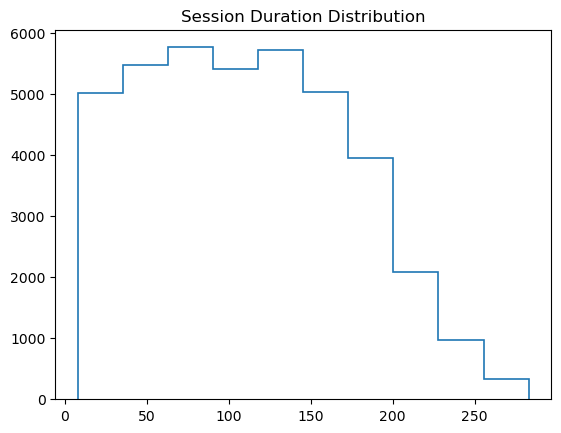

In [45]:
import matplotlib.pyplot as plt

df_clean['session_duration_min'].hist(grid=False, histtype='step', linewidth=1.2)
plt.title('Session Duration Distribution')
plt.show()
plt.close()

The distribution of session durations shows a right-skewed pattern, with most play sessions falling between approximately 30 and 160 minutes. The highest concentration of sessions occurs around the 60–140 minute range, indicating that typical gameplay sessions last roughly one to two and a half hours. Short sessions under 20 minutes are comparatively uncommon, suggesting that players who begin a session tend to play for a substantial period. A smaller number of sessions extend beyond 200 minutes, forming a long tail that likely reflects highly engaged players or extended play sessions during peak engagement periods.

#### In-Game Purchases Distribution

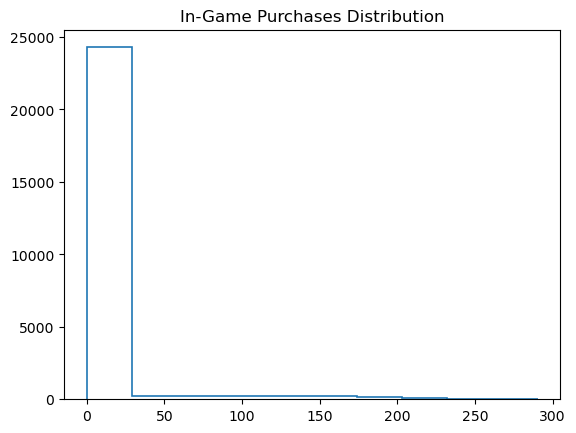

In [46]:
df_clean['in_game_purchases_usd'].hist(grid=False, histtype='step', linewidth=1.2)
plt.title('In-Game Purchases Distribution')
plt.show()
plt.close()

The distribution of in-game spending per session is heavily right-skewed, with the vast majority of sessions resulting in a spend of 0-30 USD and a small number of sessions accounting for very large purchase amounts. This is a common distribution for free-to-play games. Because spending is concentrated in this low spending figure, conversion rates are likely low, but average revenue per paying user (ARPPU) could be high. The long tail trailing towards 300 USD also suggests the presence of a small number of whales (very high spenders).

#### Social Interactions Distribution

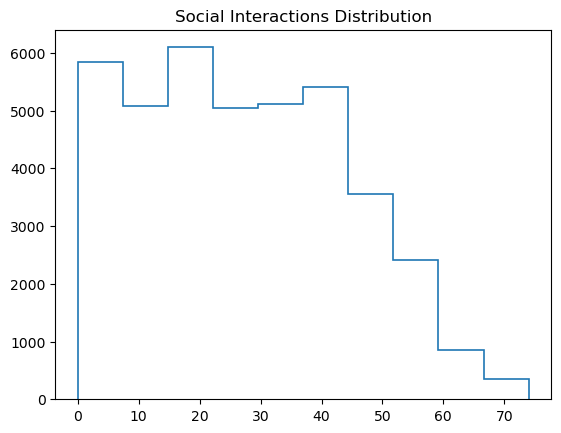

In [47]:
df_clean['social_interactions'].hist(grid=False, histtype='step', linewidth=1.2)
plt.title('Social Interactions Distribution')
plt.show()
plt.close()

The distribution of social interactions per session suggests that social engagement is a common component of gameplay. Most sessions involve roughly 10–40 interactions, indicating that players frequently engage with others during play. While some sessions show minimal interaction, a short tail of highly social sessions extends beyond 60 interactions, likely representing group play or coordinated activities. This variability highlights the importance of social features in supporting player engagement and community participation.

Having examined the general shape of these key engagement metrics, I begin to examine engagement patterns over time.

#### Average Session Duration Over Time

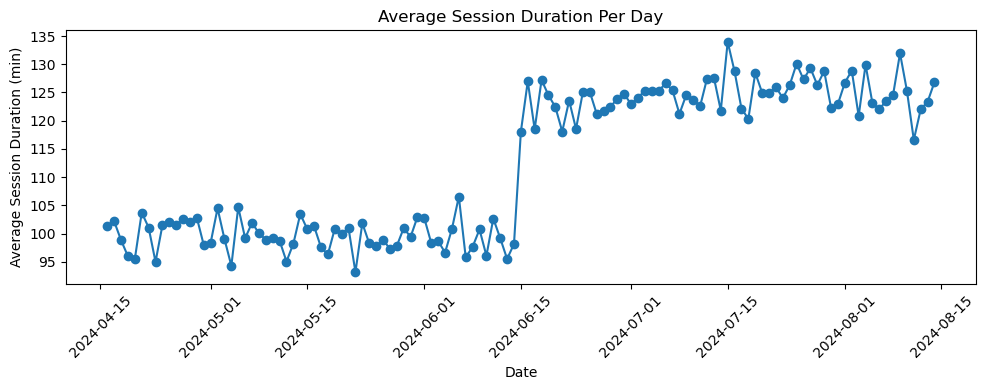

In [48]:
df_clean['date_only'] = df_clean['date'].dt.floor('D')

daily = (
    df_clean
    .groupby('date_only', as_index=False)['session_duration_min']
    .mean()
    .sort_values('date_only')
)

plt.figure(figsize=(10, 4))
plt.plot(daily['date_only'], daily['session_duration_min'], marker='o', linestyle='-')
plt.title('Average Session Duration Per Day')
plt.xlabel('Date')
plt.ylabel('Average Session Duration (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

This chart clearly shows an increase in the average duration of each play session after the launch of the content update on June 15, 2024.

#### Average Spend Per Session Over Time

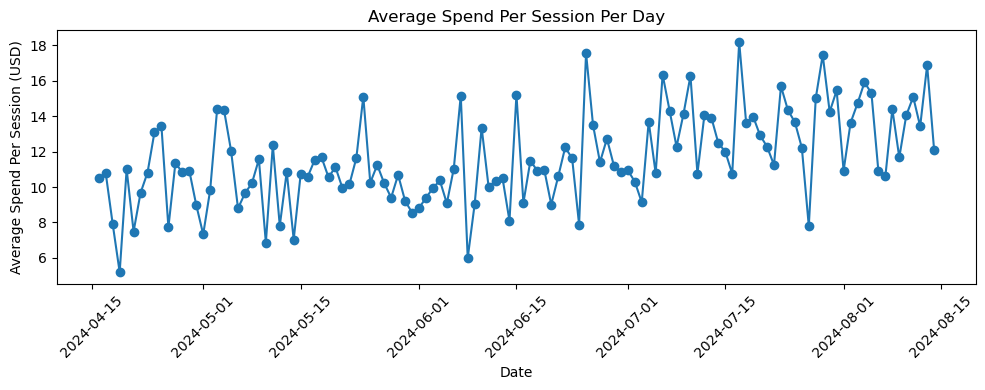

In [49]:
daily_purchases = (
    df_clean
    .groupby('date_only', as_index=False)['in_game_purchases_usd']
    .mean()
    .sort_values('date_only')
)

plt.figure(figsize=(10, 4))
plt.plot(daily_purchases['date_only'], daily_purchases['in_game_purchases_usd'], marker='o', linestyle='-')
plt.title('Average Spend Per Session Per Day')
plt.xlabel('Date')
plt.ylabel('Average Spend Per Session (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

This chart illustrates the volatility of spending on in-game purchases. However, there is a slight upwards trend over time. The drastic low point around July 27th, 2024 may require investigation. For example, it may indicate a day where the in-game store was not functioning properly or popular items were unavailable.

#### Average Number of Social Interactions Over Time

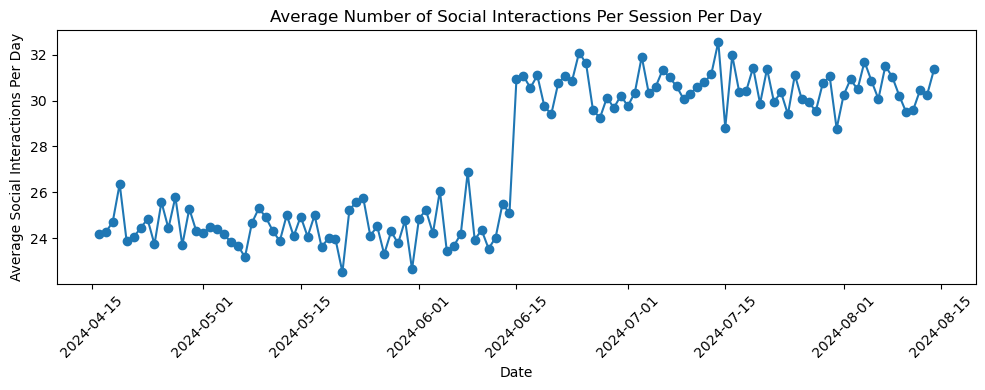

In [50]:
daily_social = (
    df_clean
    .groupby('date_only', as_index=False)['social_interactions']
    .mean()
    .sort_values('date_only')
)

plt.figure(figsize=(10, 4))
plt.plot(daily_social['date_only'], daily_social['social_interactions'], marker='o', linestyle='-')
plt.title('Average Number of Social Interactions Per Session Per Day')
plt.xlabel('Date')
plt.ylabel('Average Social Interactions Per Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

This chart shows that the average number of social interactions per session jumped drastically starting with the day of the content update. This could be attributed to the wealth of new group content such as dungeons and raids that was made available as part of the update.

#### Pre- vs Post-Update Segmentation
This section adds a column that specifies whether a session took place before or after the content update. This will support later segmentation efforts.

In [51]:
df_clean['period'] = df_clean['date_only'].apply(
    lambda x: 'pre-update' if x < pd.Timestamp('2024-06-15') else 'post-update'
)

#### Player Summary Table
This creates a player summary table that can support segmentation later.

In [52]:
player_summary = df_clean.groupby('player_id').agg({
    'session_duration_min': 'mean',
    'in_game_purchases_usd': 'sum',
    'social_interactions': 'mean',
}).reset_index()
print(player_summary.head())

   player_id  session_duration_min  in_game_purchases_usd  social_interactions
0  P00010000            116.666667                   5.52                 31.0
1  P00010001             60.250000                  30.77                27.75
2  P00010002            144.800000                   6.89                 32.2
3  P00010003            100.875000                  21.20                19.25
4  P00010004            104.000000                   9.20                16.25


#### Calculating Engagement
Before I analyze engagement and retention trends, I must create some derived metrics using this data. The code below adds additional fields to the dataset and populates those fields with values that are derived from calculations performed on existing columns in the dataset. These values will allow me to calculate the engagement score and the D1/D7/D30 retention status for each player based on the formulae laid out in the introduction to this notebook.

In [53]:
# number of unique calendar days that the player logged in on
df_clean['days_played'] = df_clean.groupby('player_id')['date_only'].transform('nunique')
players_days_played = df_clean.groupby('player_id')['date_only'].nunique()
#print(players_days_played.head())

# frequency score (days played / target days [16])
df_clean['frequency_score'] = (df_clean['days_played']/16)
players_freq = df_clean.groupby('player_id')['frequency_score'].unique()
#print(players_freq.head())


# average session duration
df_clean['average_session_duration'] = df_clean.groupby('player_id')['session_duration_min'].transform('mean')
players_avg_session_duration = df_clean.groupby('player_id')['average_session_duration'].unique()
#print(players_avg_session_duration.head())

# duration score (average session duration / target duration [30])
df_clean['duration_score'] = (df_clean['average_session_duration']/30)
players_freq = df_clean.groupby('player_id')['duration_score'].unique()
#print(players_freq.head())


# average social interactions
df_clean['average_social_interactions'] = df_clean.groupby('player_id')['social_interactions'].transform('mean')
players_avg_social_interactions = df_clean.groupby('player_id')['average_social_interactions'].unique()
#print(players_avg_social_interactions)

# social score (average social interactions / target [20])
df_clean['social_score'] = (df_clean['average_social_interactions']/20)
players_social = df_clean.groupby('player_id')['social_score'].unique()
#print(players_social.head())


# engagement score (frequency score * duration score * social score)
df_clean['engagement_score'] = (df_clean['frequency_score']*df_clean['duration_score']*df_clean['social_score'])
players_engagement = df_clean.groupby('player_id')['engagement_score'].unique()
#print(players_engagement.head())


# d1 retention status
d1_date = pd.Timestamp('2024-06-16')
df_clean['is_d1_session'] = (
    (df_clean['date_only'] == d1_date) &
    (df_clean['session_duration_min'] >= 30)
)
df_clean['d1_retained'] = (
    df_clean.groupby('player_id')['is_d1_session']
            .transform('any')      # boolean True/False per row
            .astype(int)           # convert to 1/0
)
print("Total players:", df_clean['player_id'].nunique())
print("Players retained on D1:",
      df_clean.groupby('player_id')['d1_retained'].first().sum())
print("Per-row column preview:")
print(df_clean.loc[df_clean['date_only'].isin([d1_date, d1_date - pd.Timedelta(days=1)])]
      [['player_id','date_only','session_duration_min','is_d1_session','d1_retained']].head(20))

Total players: 9575
Players retained on D1: 301
Per-row column preview:
      player_id  date_only  session_duration_min  is_d1_session  d1_retained
36    P00010010 2024-06-16                 224.0           True            1
128   P00010039 2024-06-16                 132.0           True            1
164   P00010050 2024-06-16                 193.0           True            1
189   P00010058 2024-06-15                  79.0          False            0
242   P00010074 2024-06-16                  50.0           True            1
280   P00010084 2024-06-16                  27.0          False            0
294   P00010087 2024-06-15                  49.0          False            0
304   P00010089 2024-06-16                  87.0           True            1
353   P00010101 2024-06-15                 220.0          False            1
354   P00010101 2024-06-16                  36.0           True            1
364   P00010104 2024-06-15                  57.0          False            0
646 

In [54]:
# d7 retention status
d7_date = pd.Timestamp('2024-06-22')
df_clean['is_d7_session'] = (
    (df_clean['date_only'] >= d1_date) &
    (df_clean['date_only'] <= d7_date) &
    (df_clean['session_duration_min'] >= 30)
)
df_clean['d7_retained'] = (
    df_clean.groupby('player_id')['is_d7_session']
            .transform('any')      # boolean True/False per row
            .astype(int)           # convert to 1/0
)
print("Total players:", df_clean['player_id'].nunique())
print("Players retained on D7:",
      df_clean.groupby('player_id')['d7_retained'].first().sum())
print("Per-row column preview:")
print(df_clean.loc[df_clean['date_only'].isin([d7_date, d7_date - pd.Timedelta(days=7)])]
      [['player_id','date_only','session_duration_min','is_d7_session','d7_retained']].head(20))

Total players: 9575
Players retained on D7: 1861
Per-row column preview:
      player_id  date_only  session_duration_min  is_d7_session  d7_retained
57    P00010016 2024-06-22                 181.0           True            1
165   P00010050 2024-06-22                 133.0           True            1
189   P00010058 2024-06-15                  79.0          False            0
290   P00010086 2024-06-22                  31.0           True            1
294   P00010087 2024-06-15                  49.0          False            1
295   P00010087 2024-06-22                 126.0           True            1
353   P00010101 2024-06-15                 220.0          False            1
364   P00010104 2024-06-15                  57.0          False            0
640   P00010172 2024-06-22                  20.0          False            0
646   P00010174 2024-06-15                 175.0          False            0
777   P00010206 2024-06-22                 167.0           True            1
900

In [55]:
#d30 retention status
d30_date = pd.Timestamp('2024-07-15')
df_clean['is_d30_session'] = (
    (df_clean['date_only'] >= d1_date) &
    (df_clean['date_only'] <= d30_date) &
    (df_clean['session_duration_min'] >= 30)
)
df_clean['d30_retained'] = (
    df_clean.groupby('player_id')['is_d30_session']
            .transform('any')      # boolean True/False per row
            .astype(int)           # convert to 1/0
)
print("Total players:", df_clean['player_id'].nunique())
print("Players retained on D30:",
      df_clean.groupby('player_id')['d30_retained'].first().sum())
print("Per-row column preview:")
print(df_clean.loc[df_clean['date_only'].isin([d30_date, d30_date - pd.Timedelta(days=30)])]
      [['player_id','date_only','session_duration_min','is_d30_session','d30_retained']].head(20))

Total players: 9575
Players retained on D30: 5607
Per-row column preview:
      player_id  date_only  session_duration_min  is_d30_session  d30_retained
154   P00010048 2024-07-15                 134.0            True             1
168   P00010051 2024-07-15                 245.0            True             1
189   P00010058 2024-06-15                  79.0           False             1
294   P00010087 2024-06-15                  49.0           False             1
318   P00010092 2024-07-15                 165.0            True             1
353   P00010101 2024-06-15                 220.0           False             1
364   P00010104 2024-06-15                  57.0           False             0
403   P00010112 2024-07-15                 131.0            True             1
646   P00010174 2024-06-15                 175.0           False             0
922   P00010239 2024-07-15                  53.0            True             1
1091  P00010278 2024-07-15                 105.0         

### Retention and Engagement Analysis
Here, I turn my focus from exploratory analysis to perform a targeted analysis of engagement and retention metrics. The following sections cover a basic analysis of retention rates and engagement levels. Deeper analysis is performed in Tableau (see the link at the beginning of this notebook).

#### Retention Rates by Cohort
I begin my targeted analysis by examining the rates of D1/D7/D30 retention by account age.

In [56]:
df_retention = df_clean.copy()

df_retention['account_age_category'] = df_retention['account_age_category'].fillna('Unknown').astype(str)

per_player_d1 = (
    df_retention.groupby('player_id', as_index=False)
      .agg(account_age_category=('account_age_category', 'first'),
           d1_retained=('d1_retained', 'max'))
)
summary_d1 = (
    per_player_d1
      .groupby('account_age_category', dropna=False)
      .agg(players=('player_id', 'nunique'),
           retained_count=('d1_retained', 'sum'))
      .assign(retention_pct=lambda x: (x['retained_count'] / x['players']) * 100)
      .sort_values('retention_pct', ascending=False)
      .reset_index()
)

summary_d1['retention_pct'] = summary_d1['retention_pct'].round(2)
print("D1 RETENTION BY ACCOUNT AGE")
print(summary_d1)

D1 RETENTION BY ACCOUNT AGE
  account_age_category  players  retained_count  retention_pct
0              Unknown     1652              58           3.51
1                  NEW     3168             106           3.35
2         INTERMEDIATE     1579              48           3.04
3              VETERAN     3176              89           2.80


In [57]:
per_player_d7 = (
    df_retention.groupby('player_id', as_index=False)
      .agg(account_age_category=('account_age_category', 'first'),
           d7_retained=('d7_retained', 'max'))
)
summary_d7 = (
    per_player_d7
      .groupby('account_age_category', dropna=False)
      .agg(players=('player_id', 'nunique'),
           retained_count=('d7_retained', 'sum'))
      .assign(retention_pct=lambda x: (x['retained_count'] / x['players']) * 100)
      .sort_values('retention_pct', ascending=False)
      .reset_index()
)

summary_d7['retention_pct'] = summary_d7['retention_pct'].round(2)
print("D7 RETENTION BY ACCOUNT AGE")
print(summary_d7)

D7 RETENTION BY ACCOUNT AGE
  account_age_category  players  retained_count  retention_pct
0                  NEW     3168             643          20.30
1              Unknown     1652             317          19.19
2              VETERAN     3176             602          18.95
3         INTERMEDIATE     1579             299          18.94


In [58]:
per_player_d30 = (
    df_retention.groupby('player_id', as_index=False)
      .agg(account_age_category=('account_age_category', 'first'),
           d30_retained=('d30_retained', 'max'))
)
summary_d30 = (
    per_player_d30
      .groupby('account_age_category', dropna=False)
      .agg(players=('player_id', 'nunique'),
           retained_count=('d30_retained', 'sum'))
      .assign(retention_pct=lambda x: (x['retained_count'] / x['players']) * 100)
      .sort_values('retention_pct', ascending=False)
      .reset_index()
)

summary_d30['retention_pct'] = summary_d30['retention_pct'].round(2)
print("D30 RETENTION BY ACCOUNT AGE")
print(summary_d30)

D30 RETENTION BY ACCOUNT AGE
  account_age_category  players  retained_count  retention_pct
0              VETERAN     3176            1878          59.13
1                  NEW     3168            1860          58.71
2         INTERMEDIATE     1579             919          58.20
3              Unknown     1652             950          57.51


#### Engagement Distribution
I examine the shape of the engagement scores present in the data.

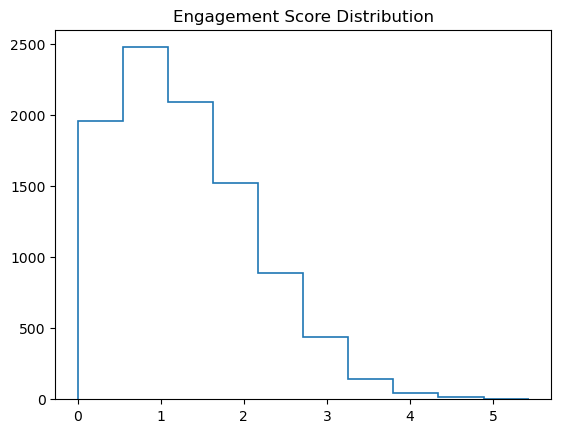

Median Engagement Score: 1.1717013888888888


In [59]:
df_copy = df_clean.copy()
df_eng_and_ret = df_copy.drop_duplicates(subset=['player_id'])

df_eng_and_ret['engagement_score'].hist(grid=False, histtype='step', linewidth=1.2)
plt.title('Engagement Score Distribution')
plt.show()
plt.close()

print(f"Median Engagement Score: {df_eng_and_ret['engagement_score'].median()}")

In [60]:
engaged_players = (df_eng_and_ret['engagement_score'] >= 1).sum()
print(f"Engaged players: {engaged_players}")

percent_engaged = ((engaged_players / len(df_eng_and_ret)) * 100).round(2)
print(f"Engaged players make up {percent_engaged}% of our sample.")

Engaged players: 5532
Engaged players make up 57.78% of our sample.


A majority of players meet the "engaged" benchmark, with a very small number of highly engaged players causing the distribution of engagement scores to skew right.